In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib import patches
from matplotlib.cm import ScalarMappable
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from streamtracer import StreamTracer, VectorGrid
from extrapolater import PotentialField
from helpers import from_local

import h5py 
import dask.array as da 
from ndcube import NDCube
from fancy_colorbar import plot_colorbar



import sys
sys.path.append("/cluster/home/zhuyin/scripts/MHSXtraPy/")

from mhsxtrapy.b3d import WhichSolution
from mhsxtrapy.examples import multipole
from mhsxtrapy.field2d import Field2dData, FluxBalanceState, check_fluxbalance
from mhsxtrapy.field3d import calculate_magfield, Field3dData
from mhsxtrapy.plotting.vis import (
    plot_ddensity_xy,
    plot_ddensity_z,
    plot_dpressure_xy,
    plot_dpressure_z,
    plot_magnetogram_2D,
    plot_magnetogram_3D,
)

In [20]:
file_hri_pr_noproj_dset = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/HRIEUV_noproj_pr.hdf5")
hri_pr_noproj_array = file_hri_pr_noproj_dset["hrieuv_noproj_img"][:]
hrieuv_no_proj_extent = np.load("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hrieuv_no_proj_extent.npy")
hrieuv_nocrop_noproj_wcs = WCS(fits.getheader("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hri_nocrop_noproj_wcs.fits",
                                        ignore_missing_simple=True))
hrieuv_noproj_wcs = hrieuv_nocrop_noproj_wcs[hrieuv_no_proj_extent[1]:hrieuv_no_proj_extent[3] + 1,
                                hrieuv_no_proj_extent[0]:hrieuv_no_proj_extent[2] + 1]
hrieuv_date_ear = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])

In [3]:
data3d = Field3dData.load("../../data/pid_1_123_aux/MHSXtra_results/SOTSP_test_full/")

In [4]:
nx, ny, nz, nf = 960, 540, 540, 540
# xmin, xmax, ymin, ymax, zmin, zmax = 0.0, 1.0, 0.0, 1.0, 0.0, 1.0

pixelsize_x = 0.23712652199468398
pixelsize_y = pixelsize_x
pixelsize_z = pixelsize_x

# x_arr = np.linspace(xmin, xmax, nx, dtype=np.float64)
# y_arr = np.linspace(ymin, ymax, ny, dtype=np.float64)
# z_arr = np.linspace(zmin, zmax, nz, dtype=np.float64)
x_arr = np.arange(nx) * pixelsize_x
y_arr = np.arange(ny) * pixelsize_y
z_arr = np.arange(nz) * pixelsize_z

In [5]:
bx_extra = data3d.field[:,:,:,1]
by_extra = data3d.field[:,:,:,0]
bz_extra = data3d.field[:,:,:,2]

bx_extra = bx_extra[ny:ny*2, nx:nx*2,:]
by_extra = by_extra[ny:ny*2, nx:nx*2,:]
bz_extra = bz_extra[ny:ny*2, nx:nx*2,:]

In [6]:
field_array = np.array([bx_extra.transpose(1,0,2), by_extra.transpose(1,0,2), bz_extra.transpose(1,0,2)]).transpose(1,2,3,0)

In [7]:
field_grid = VectorGrid(field_array, grid_coords=[x_arr, y_arr, z_arr])

In [8]:
seeds = np.array([[ii, jj, 0] for ii in np.linspace(x_arr[430], x_arr[590], 24) for jj in np.linspace(y_arr[220], y_arr[380], 24)])

In [9]:
nsteps = 10000
step_size = 0.02
tracer = StreamTracer(nsteps, step_size)
tracer.trace(seeds, field_grid)

In [10]:
sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.fits")

In [11]:
fline_hgs = []

for fline in tracer.xs[:]:
    # if fline[-1,2] < 60:
    fline_hgs_ = sotsp_br_map.wcs.pixel_to_world(fline[:,0]/pixelsize_x, fline[:,1]/pixelsize_y)
    fline_hgs_ = SkyCoord(lon=fline_hgs_.lon, lat=fline_hgs_.lat, radius=fline[:,2]*u.Mm + 695700*u.km,
                        frame=fline_hgs_.frame)
    
    fline_hgs.append(fline_hgs_)

In [13]:
def colored_line_with_alpha(x, y, c, ax, norm_color, norm_alpha, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    cmap = plt.get_cmap(default_kwargs.pop("cmap", "plasma"))
    color_rgb = cmap(norm_color(c))
    color_rgb[:,-1] = 1 - norm_alpha(c)*0.9

    lc = LineCollection(segments, colors=color_rgb, **default_kwargs)
    # lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [16]:
fline_vbi_pixel = []

for fline in fline_hgs[:]:
    with propagate_with_solar_surface():
        fline_pixel_x, fline_pixel_y = hrieuv_noproj_wcs.world_to_pixel(fline)
    fline_vbi_pixel.append([fline_pixel_x, fline_pixel_y, fline.radius.to_value(u.Mm) - 695.7])


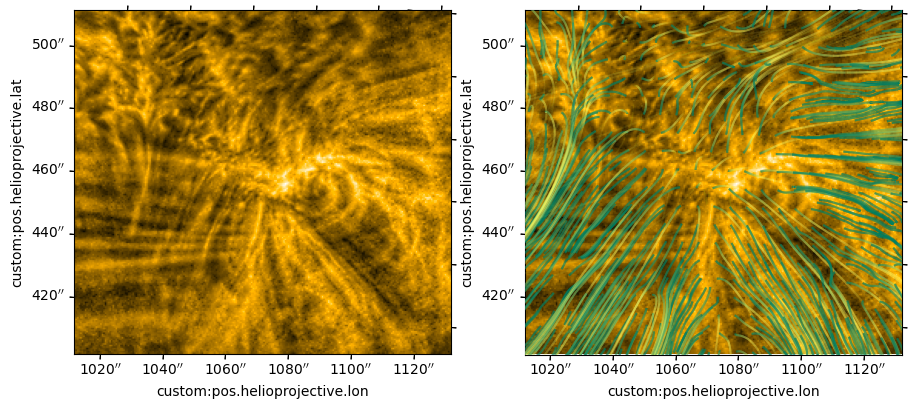

: 

In [23]:
with plt.style.context('default'):
    fig = plt.figure(figsize=(9,4), layout="constrained")

    optimal_time = Time("2022-10-24T19:11:13")
    hri_index = np.argmin(np.abs(hrieuv_date_ear - optimal_time))

    ax1 = fig.add_subplot(121, projection=hrieuv_noproj_wcs)
    im1 = ax1.imshow(hri_pr_noproj_array[hri_index,:,:], origin="lower", cmap="sdoaia171")

    ax2 = fig.add_subplot(122, projection=hrieuv_noproj_wcs)
    im2 = ax2.imshow(hri_pr_noproj_array[hri_index,:,:], origin="lower", cmap="sdoaia171")

    for ax_ in (ax2,):
        ax_lim = ax_.axis()
    
        for fline in fline_vbi_pixel[:]:
                colored_line_with_alpha(fline[0], fline[1], fline[2], ax_, cmap="summer",
                norm_color=ImageNormalize(vmin=0,vmax=2, clip=True),
                norm_alpha=ImageNormalize(vmin=0,vmax=5, clip=True),
                lw=1.5)

        ax_.axis(ax_lim)